In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from scipy.stats import spearmanr
from tqdm import tqdm

from src.enhanced_cewa import ClassificationCEWA

from typing import Tuple, List

## Methods to generate data

### We intentionally applied noise to labels during the model training - to see that good annotators can help improve the labels in CEWA method even if model was trained on noisy labels See preparations in prepare_probabilities.ipynb

In [23]:
def create_food101N_annotation_dataframe(df: pd.DataFrame, n_annotators: int = 100,
                              agreement_bounds: Tuple[float, float] = (0.51, 0.91)) -> pd.DataFrame:
    n_images = len(df)
    all_possible_labels = sorted(df['food_label'].unique())
    
    df_copy = df.copy()
    df_copy['_available_food_labels'] = [all_possible_labels] * len(df)
    
    annotation_df = pd.DataFrame(
        np.full((n_images, n_annotators), np.nan),
        columns=[f'annotator_{i}' for i in range(n_annotators)]
    )
    
    annotator_quality = create_annotator_quality_profiles(n_annotators)
    
    for img_idx, row in tqdm(df_copy.iterrows(), total=len(df_copy)):
        img_idx -= 1
        true_food_label = row['food_label']
        is_clean = row['label'] == 1
        
        selected_annotators = select_annotators_for_image(n_annotators)
        
        dominant_label = get_dominant_label_for_image(row)
        agreement_percentage = get_agreement_percentage(agreement_bounds)
        
        remaining_annotators = assign_dominant_labels(
            annotation_df, img_idx, selected_annotators, dominant_label, agreement_percentage
        )
        
        assign_remaining_labels(
            annotation_df, img_idx, remaining_annotators, true_food_label,
            dominant_label, annotator_quality, all_possible_labels
        )
    
    return annotation_df, annotator_quality

def create_annotator_quality_profiles(n_annotators: int) -> List[float]:
    quality_scores = np.concatenate([
        np.random.uniform(0.1, 0.3, size=int(0.3 * n_annotators)),  # Bad annotators
        np.random.uniform(0.3, 0.7, size=int(0.4 * n_annotators)),  # Average annotators  
        np.random.uniform(0.7, 0.95, size=int(0.3 * n_annotators))  # Good annotators
    ])
    
    quality_scores = quality_scores[:n_annotators]
    np.random.shuffle(quality_scores)
    
    return quality_scores.tolist()

def select_annotators_for_image(n_annotators: int) -> List[int]:
    n_annotators_this_image = np.random.randint(10, 21)
    return np.random.choice(n_annotators, size=n_annotators_this_image, replace=False).tolist()

def get_agreement_percentage(agreement_bounds: Tuple[float, float]) -> float:
    return np.random.uniform(agreement_bounds[0], agreement_bounds[1])

def get_dominant_label_for_image(row: pd.Series) -> int:
    if row['label'] == 1:
        # Clean case - use the actual food_label
        return row['food_label']
    else:
        # Noisy case - randomly choose from available food labels in the dataset
        # This simulates cases where the image was mislabeled
        available_labels = row.get('_available_food_labels', [row['food_label']])
        return np.random.choice(available_labels)

def assign_dominant_labels(annotation_df: pd.DataFrame, img_idx: int,
                          annotators: List[int], dominant_label: int,
                          percentage: float) -> List[int]:
    n_dominant = int(len(annotators) * percentage)
    dominant_annotators = np.random.choice(annotators, size=n_dominant, replace=False)
    
    for annotator_idx in dominant_annotators:
        annotation_df.iloc[img_idx, annotator_idx] = dominant_label
    
    return [a for a in annotators if a not in dominant_annotators]

def assign_remaining_labels(annotation_df: pd.DataFrame, img_idx: int,
                           annotators: List[int], true_food_label: int,
                           dominant_label: int, annotator_quality: List[float],
                           all_possible_labels: List[int]):
    for annotator_idx in annotators:
        quality = annotator_quality[annotator_idx]
        
        if np.random.random() < quality:
            # Good decision - give the TRUE food label (not necessarily the dominant one)
            annotation_df.iloc[img_idx, annotator_idx] = true_food_label
        else:
            # Make a mistake - give random label
            annotation_df.iloc[img_idx, annotator_idx] = np.random.choice(all_possible_labels)

def validate_annotation_df(annotation_df: pd.DataFrame, original_df: pd.DataFrame) -> dict:
    annotations_per_image = annotation_df.notna().sum(axis=1)
    
    clean_indices = original_df[original_df['label'] == 1].index
    noisy_indices = original_df[original_df['label'] == 0].index
    
    validation_stats = {
        'min_annotations_per_image': annotations_per_image.min(),
        'max_annotations_per_image': annotations_per_image.max(), 
        'mean_annotations_per_image': annotations_per_image.mean(),
        'n_unique_annotators': annotation_df.shape[1],
        'nan_percentage': annotation_df.isna().sum().sum() / (annotation_df.shape[0] * annotation_df.shape[1]),
        'n_clean_images': len(clean_indices),
        'n_noisy_images': len(noisy_indices)
    }
    
    return validation_stats

In [24]:
path = r"data/clean_101n_filtered_with_noisy_column.csv"
df = pd.read_csv(path)[1:]
ground_truth_food101N = np.array(df["food_label"].to_list())

In [25]:
# Here we are going to simulate 100 annotators with different labeling skill
# So some of them - correct and some add noise in labeling
ann_data = create_food101N_annotation_dataframe(df, n_annotators=100, agreement_bounds = (0.51,0.91))
food101N_annotation_df, food101N_annotator_quality = ann_data

(52866, 5)


100%|██████████| 52866/52866 [01:36<00:00, 546.65it/s]


## Load model predictions 

In [27]:
path = r"data/swin_food101n_probabilities.csv"
model_probs_food101N_dataset = pd.read_csv(path)
model_probs_food101N_dataset = model_probs_food101N_dataset.to_numpy()

## Run CEWA

In [45]:
def evaluate_cewa(annotations, model_probs, ground_truth, use_majority_vote=False):
    if not isinstance(annotations, pd.DataFrame):
        annotations = pd.DataFrame(annotations)

    cewa = ClassificationCEWA(
        n_classes=model_probs.shape[1],
        use_majority_vote=use_majority_vote
    )
    cewa.fit(annotations, model_probs)
    consensus_labels, quality_scores, _ = cewa.predict_consensus(annotations, model_probs)
    annotator_scores = cewa.score_annotators(annotations)

    correct = (consensus_labels == ground_truth).astype(int)
    acc = accuracy_score(ground_truth, consensus_labels)
    auroc = roc_auc_score(correct, quality_scores)
    auprc = average_precision_score(correct, quality_scores)

    ann_np = annotations.to_numpy(dtype=float)
    true_accs = []
    for j in range(ann_np.shape[1]):
        valid = ~np.isnan(ann_np[:, j])
        if np.any(valid):
            true_accs.append(accuracy_score(
                ground_truth[valid],
                ann_np[valid, j].astype(int)
            ))
        else:
            true_accs.append(0.0)
    corr = spearmanr(annotator_scores, true_accs).correlation

    return {
        'accuracy': acc,
        'auroc': auroc,
        'auprc': auprc,
        'annotator_correlation': corr
    }

In [46]:
results = {
    'food101N': {},
}

In [47]:
print("Running EnhancedCEWA...")
results['food101N']['cewa'] = evaluate_cewa(food101N_annotation_df, model_probs_food101N_dataset, np.array(ground_truth_food101N) , use_majority_vote=False)

Running EnhancedCEWA...


computing annotator matrices: 100%|██████████| 100/100 [00:12<00:00,  8.25it/s]
2026-08-11 11:29:42,614 - src.enhanced_cewa - INFO - ClassificationCEWA metrics computed
calculating better labels: 100%|██████████| 52866/52866 [00:11<00:00, 4602.71it/s]


In [48]:
print("Running Majority Vote. Here only accuracy has value")
results['food101N']['majority'] = evaluate_cewa(food101N_annotation_df, model_probs_food101N_dataset, np.array(ground_truth_food101N), use_majority_vote=True)

2026-08-11 11:29:55,489 - src.enhanced_cewa - INFO - Using majority vote, skipping metric computation


Running Majority Vote...


C:\Users\skasay\AppData\Local\Temp\ipykernel_16548\2990309966.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(annotator_scores, true_accs).correlation


In [41]:
print("\n=== Results ===")
for dataset in ['food101N']:
    print(f"\n{dataset.upper()} dataset:")
    for method in ['cewa', 'majority']:
        print(f"  {method.upper()}:")
        for k, v in results[dataset][method].items():
            print(f"    {k}: {v:.4f}")


=== Results ===

FOOD101N dataset:
  CEWA:
    accuracy: 0.8289
    auroc: 0.7780
    auprc: 0.9437
    annotator_correlation: 0.9978
  MAJORITY:
    accuracy: 0.8177
    auroc: 0.5000
    auprc: 0.8177
    annotator_correlation: nan


## Visualize metrics

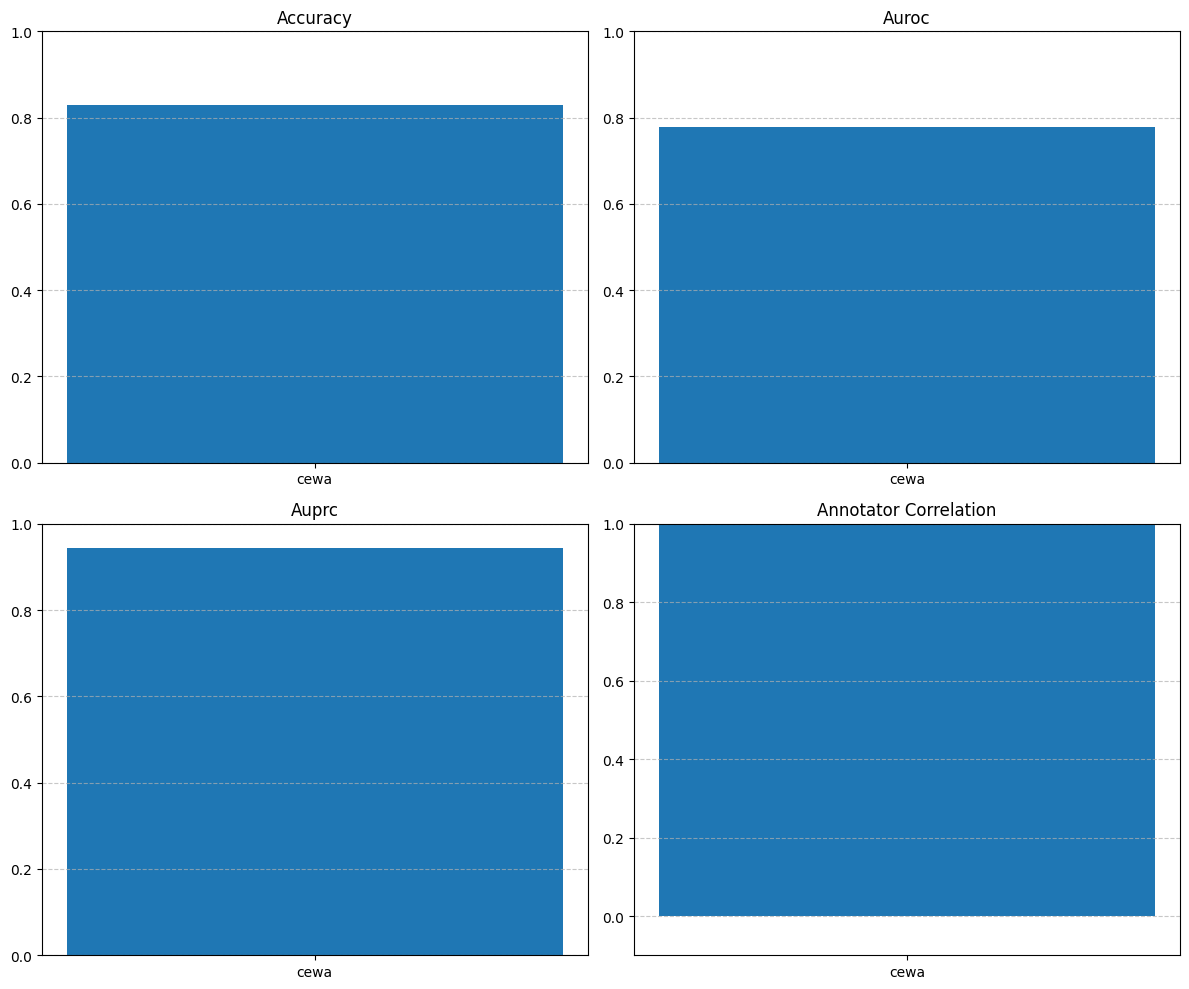

In [51]:
metrics = ['accuracy', 'auroc', 'auprc', 'annotator_correlation']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = [results['food101N']['cewa'][metric]]
    ax.bar(['cewa'], values, color=['#1f77b4'])
    ax.set_title(metric.replace('_', ' ').title())
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if metric in ['accuracy', 'auroc', 'auprc']:
        ax.set_ylim(0, 1)
    else:
        ax.set_ylim(-0.1, 1)

plt.tight_layout()
plt.savefig('cewa_food101N_evaluation.png', dpi=150)
plt.show()

### P.S. The final label quality also deeply depends on the quality of model predictions